# Brain Tumor MRI Classification – Training

This notebook trains an image classification model using **EfficientNetB0**.

Outputs:
- Accuracy graph
- Confusion Matrix
- Classification Report
- Saved `.h5` model for Flask deployment

In [1]:

# 4. Unzip it
!unzip d.zip -d dataset

Archive:  d.zip
   creating: dataset/dataset/
   creating: dataset/dataset/Glioma/
  inflating: dataset/dataset/Glioma/gg (1).jpg  
  inflating: dataset/dataset/Glioma/gg (103).jpg  
  inflating: dataset/dataset/Glioma/gg (104).jpg  
  inflating: dataset/dataset/Glioma/gg (105).jpg  
  inflating: dataset/dataset/Glioma/gg (106).jpg  
  inflating: dataset/dataset/Glioma/gg (107).jpg  
  inflating: dataset/dataset/Glioma/gg (108).jpg  
  inflating: dataset/dataset/Glioma/gg (109).jpg  
  inflating: dataset/dataset/Glioma/gg (11).jpg  
  inflating: dataset/dataset/Glioma/gg (110).jpg  
  inflating: dataset/dataset/Glioma/gg (111).jpg  
  inflating: dataset/dataset/Glioma/gg (112).jpg  
  inflating: dataset/dataset/Glioma/gg (114).jpg  
  inflating: dataset/dataset/Glioma/gg (115).jpg  
  inflating: dataset/dataset/Glioma/gg (116).jpg  
  inflating: dataset/dataset/Glioma/gg (117).jpg  
  inflating: dataset/dataset/Glioma/gg (118).jpg  
  inflating: dataset/dataset/Glioma/gg (119).jpg  
  

In [2]:
#@title Prepare splits
import random, shutil
from pathlib import Path
import os

random_seed = 42  #@param {type:"integer"}
train_ratio = 0.8  #@param {type:"number"}
val_ratio = 0.1    #@param {type:"number"}
test_ratio = 0.1   #@param {type:"number"}

assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, "Ratios must sum to 1."

dataset = 'dataset/dataset' # Define the dataset variable with the correct path
root = Path(dataset)

# Diagnostic: Print current working directory and its contents
print(f"Current working directory: {os.getcwd()}")
print(f"Contents of /content: {os.listdir('/content')}")
if Path('dataset').exists():
    print(f"Contents of /content/dataset: {os.listdir('/content/dataset')}")

assert root.exists(), f"Data path not found: {root}. Please ensure the previous cell (download and unzip) has been run successfully."

# If already split, use it.
if (root / "train").exists() and (root / "val").exists():
    split_root = root
    print("Detected existing split at:", split_root.resolve())
else:
    # Expecting ImageFolder: root//*.jpg
    classes = [d.name for d in root.iterdir() if d.is_dir()]
    assert len(classes) > 0, f"No class subfolders found under {root}"
    split_root = Path("/content/data_split")
    (split_root / "train").mkdir(parents=True, exist_ok=True)
    (split_root / "val").mkdir(parents=True, exist_ok=True)
    (split_root / "test").mkdir(parents=True, exist_ok=True)

    random.seed(random_seed)
    for cls in classes:
        files = [p for p in (root / cls).glob("*") if p.is_file()]
        random.shuffle(files)
        n = len(files)
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)
        train_files = files[:n_train]
        val_files = files[n_train:n_train+n_val]
        test_files = files[n_train+n_val:]

        for subset_name, subset_files in [("train", train_files), ("val", val_files), ("test", test_files)]:
            dest_dir = split_root / subset_name / cls
            dest_dir.mkdir(parents=True, exist_ok=True)
            for f in subset_files:
                shutil.copy2(f, dest_dir / f.name)

    print("Created split at:", split_root.resolve())

train_dir = split_root / "train"
val_dir = split_root / "val"
test_dir = split_root / "test" if (split_root / "test").exists() else None
print("train_dir:", train_dir)
print("val_dir:", val_dir)
print("test_dir:", test_dir)

Current working directory: /content
Contents of /content: ['.config', 'dataset', 'd.zip', 'sample_data']
Contents of /content/dataset: ['dataset']
Created split at: /content/data_split
train_dir: /content/data_split/train
val_dir: /content/data_split/val
test_dir: /content/data_split/test


In [10]:

# ===== SETUP =====
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


## Dataset Structure
```
dataset_brain/
 ├── train/
 ├── val/
 └── test/
```
Each class must be inside its own folder.

In [11]:

# ===== CONFIG =====
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 8

DATASET_DIR = "/content/dataset_brain"
MODEL_DIR = "/content/models"
os.makedirs(MODEL_DIR, exist_ok=True)


In [12]:

# ===== DATA LOADER =====
def load_datasets(path):
    train_ds = tf.keras.preprocessing.image_dataset_from_directory(
        os.path.join(path, "train"),
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE
    )
    val_ds = tf.keras.preprocessing.image_dataset_from_directory(
        os.path.join(path, "val"),
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE
    )
    test_ds = tf.keras.preprocessing.image_dataset_from_directory(
        os.path.join(path, "test"),
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE
    )
    return train_ds, val_ds, test_ds, train_ds.class_names


In [13]:

# ===== MODEL =====
def build_model(num_classes):
    base = tf.keras.applications.EfficientNetB0(
        include_top=False, weights="imagenet", input_shape=(224,224,3)
    )
    base.trainable = False

    inputs = keras.Input(shape=(224,224,3))
    x = tf.keras.applications.efficientnet.preprocess_input(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


Found 3788 files belonging to 4 classes.
Found 472 files belonging to 4 classes.
Found 477 files belonging to 4 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 342s 3s/step - accuracy: 0.5623 - loss: 1.0228 - val_accuracy: 0.8496 - val_loss: 0.4791
Epoch 2/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 316s 3s/step - accuracy: 0.8242 - loss: 0.5096 - val_accuracy: 0.8792 - val_loss: 0.3788
Epoch 3/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 326s 3s/step - accuracy: 0.8490 - loss: 0.4310 - val_accuracy: 0.8835 - val_loss: 0.3335
Epoch 4/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 385s 3s/step - accuracy: 0.8676 - loss: 0.3669 - val_accuracy: 0.9025 - val_loss: 0.3066
Epoch 5/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 310s 3s/step - accuracy: 0.8766 - loss: 0.3500 - val_accuracy: 0.8919 - val_loss: 0.2895
Epoch 6/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 340s 3s/step - accuracy: 0.8848 - loss: 0.3308 - val_accuracy: 0.8983 - val_loss: 0.2731
Epoch 7/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 364s 3s/step - accura

Model saved at: /content/models/brain_model.h5


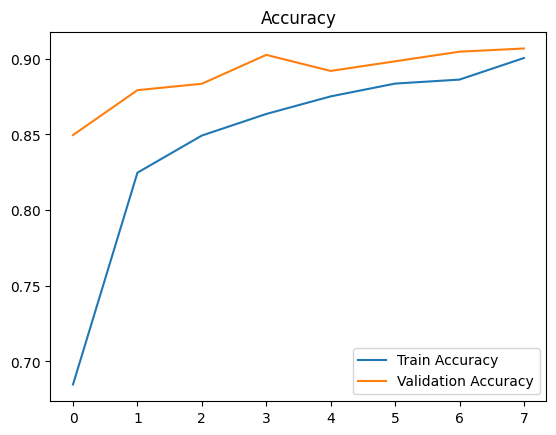

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


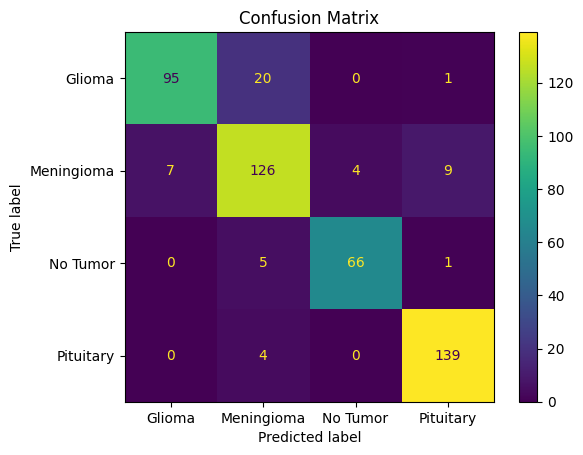

              precision    recall  f1-score   support

      Glioma       0.93      0.82      0.87       116
  Meningioma       0.81      0.86      0.84       146
    No Tumor       0.94      0.92      0.93        72
   Pituitary       0.93      0.97      0.95       143

    accuracy                           0.89       477
   macro avg       0.90      0.89      0.90       477
weighted avg       0.90      0.89      0.89       477



In [14]:

# ===== TRAIN & EVALUATE =====
train_ds, val_ds, test_ds, class_names = load_datasets(DATASET_DIR)
model = build_model(len(class_names))

history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

model_path = os.path.join(MODEL_DIR, "brain_model.h5")
model.save(model_path)
print("Model saved at:", model_path)

# Accuracy plot
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy")
plt.legend()
plt.show()

# Confusion Matrix
y_true, y_pred = [], []
for imgs, labels in test_ds:
    preds = model.predict(imgs)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="viridis")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))


### Next Step
Download the generated `.h5` model and use it in your Flask app.